# 2.4.3 在输入跳变处分段计算

## 学习目标与先修知识

能构造包含输入（input）跳变的时间网格（time grid），用实际步长更新，并独立传播分段解析参考，区分规则一致性容差与离散误差。

先修：欧拉法（forward Euler method）更新、恒定输入解析解（analytical solution）及前两节的误差检查。 [复习上一节](02-稳定性与非负性不是一回事.ipynb)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

输入在 t=3 T 突然停止，名义步长却是 0.8 T。若一步从 2.4 走到 3.2 T，该按哪一个速率计算？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()

## 初步实验

先按给定条件计算，再用后面的推导解释结果。

In [2]:
print('不分段的名义点：',[round(.8*i,1) for i in range(5)])
print('跨过跳变的区间：2.4 → 3.2 T')
print('应拆为：2.4 → 3.0 T，以及 3.0 之后的新输入区间')

不分段的名义点： [0.0, 0.8, 1.6, 2.4, 3.2]
跨过跳变的区间：2.4 → 3.2 T
应拆为：2.4 → 3.0 T，以及 3.0 之后的新输入区间


## 模型假设

u(t) 在给定严格递增边界之间恒定，取左闭右开约定；有限速率跳变，所追踪物质总量（tracked amount）不瞬间跳跃。k 在各段相同。使用同一个 A0 分别开始数值解与参考解，再各自连续传播；所有数值为人工案例。

## 数学解释与推导

对区间 $[b_j,b_{j+1}]$，从左端重新放置名义点 $b_j+h,b_j+2h,\ldots$；最后一步不足 h 就缩短到右端。各边界只加入一次。

数值更新必须用 $\Delta t_i=t_{i+1}-t_i$：
$$A_{i+1}=A_i+\Delta t_i(u_j-kA_i).$$
在 [2.4,3] 段仍用旧流率（flow rate），时长只有 0.6 T；到达 3 后再切换速率。给曲线补画一个跳变标记，不能修复已经跨段算错的累计量。

独立参考利用恒定输入解。定义传播函数 $\Phi(\Delta t;u,k,A)$ 为上一章的解析解，则
$$A_{\rm ref}(b_{j+1})=\Phi(b_{j+1}-b_j;u_j,k,A_{\rm ref}(b_j)).$$
段内时刻也从**该段解析起点**计算，不从欧拉值重新开始；否则两条轨迹（trajectory）的误差会被偷偷清零。参考轨迹在边界连续，变化率可以跳变。

若 k=0，终值必须满足 $A(T)=A_0+\sum_j u_j(b_{j+1}-b_j)$，与网格无关。它是特别有用的独立边界检查。公式实现的浮点容差与相对连续模型（model）的离散误差是两种标准，不能相互替代。

## 核心实现

函数只接收本节定义的量；核心计算步骤如下。

In [3]:
def aligned_grid(bounds, h):
    import math
    times = [bounds[0]]
    for left, right in zip(bounds, bounds[1:]):
        count = math.ceil((right - left) / h - 1e-12)
        for i in range(1, count + 1):
            # Restart at each change point, keeping the exact final boundary.
            times.append(right if i == count else left + i * h)
    return times

def exact_amount(time, u, k, A0):
    import math
    if k == 0:
        return A0 + u * time
    # expm1(z)/z tends to 1; this avoids both cancellation and a huge u/k.
    z = -k * time
    ratio = 1.0 if z == 0 else math.expm1(z) / z
    return A0 * math.exp(z) + u * time * ratio

def exact_series(A0, u, k, times):
    return [exact_amount(t, u, k, A0) for t in times]

def piecewise(A0, k, bounds, rates, h):
    times = aligned_grid(bounds, h)
    amounts, reference = [A0], [A0]
    segment = 0
    exact_at_start = A0
    for left, right in zip(times, times[1:]):
        if segment + 1 < len(rates) and left >= bounds[segment + 1] - 1e-12:
            exact_at_start = exact_amount(bounds[segment + 1] - bounds[segment],
                                          rates[segment], k, exact_at_start)
            segment += 1
        rate = rates[segment]
        duration = right - left
        amounts.append(amounts[-1] + duration * (rate - k * amounts[-1]))
        reference.append(exact_amount(right - bounds[segment], rate, k, exact_at_start))
    return times, amounts, reference

## 对照实验

| t / T | 欧拉 / U | 解析 / U |
| --- | --- | --- |
| 0 | 0 | 0 |
| 0.8 | 1.6 | 1.31872 |
| 1.6 | 2.56 | 2.20268 |
| 2.4 | 3.136 | 2.79522 |
| 3 | 3.3952 | 3.10748 |
| 3.8 | 2.03712 | 2.08301 |
| 4.6 | 1.22227 | 1.39628 |
| 5 | 0.977818 | 1.14318 |

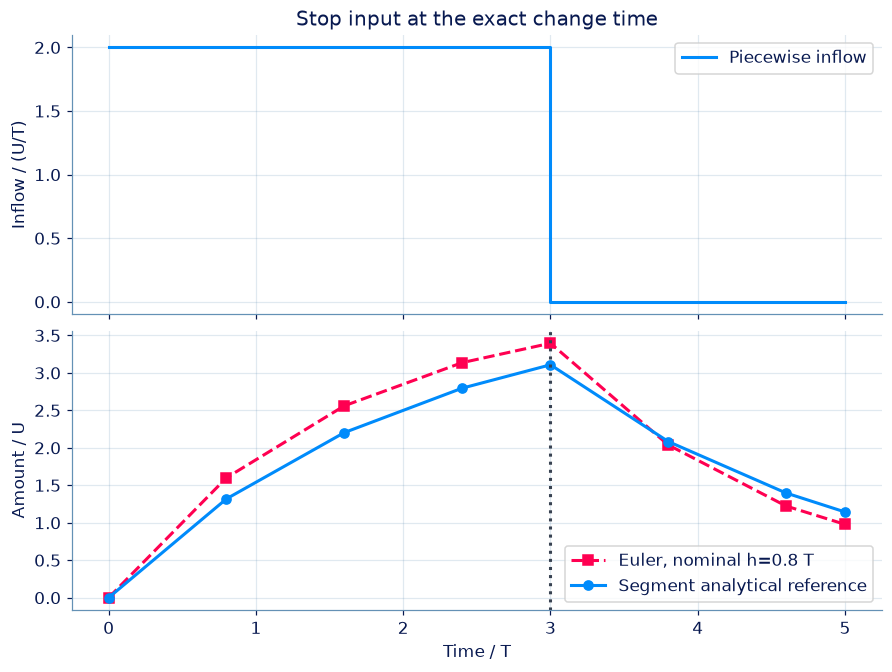

In [4]:
bounds,rates,h=[0,3,5],[2,0],.8
times,amounts,reference=piecewise(0,.5,bounds,rates,h)
display(Markdown(show_table(['t / T','欧拉 / U','解析 / U'],zip(times,amounts,reference))))
fig,axes=plt.subplots(2,1,figsize=(8,6),sharex=True)
axes[0].step(bounds,[*rates,rates[-1]],where='post',label='Piecewise inflow')
axes[0].set(ylabel='Inflow / (U/T)',title='Stop input at the exact change time');axes[0].legend()
axes[1].plot(times,amounts,'s--',color='#ff0051',label='Euler, nominal h=0.8 T')
axes[1].plot(times,reference,'o-',color='#008bfb',label='Segment analytical reference')
axes[1].axvline(3,color='#384251',ls=':')
axes[1].set(xlabel='Time / T',ylabel='Amount / U');axes[1].legend();plt.show()

## 结果解释

网格包含 3 和 5，末段实际时长不是都等于 0.8 T。停止输入后总量继续保持连续，并因清除开始下降。图中解析参考的点间连线仅作引导，真实连续形状由段内指数表达给出。

### 独立核对

对本节固定步长方法，应让步骤在已知跳变处结束。使用其他求解器时，也应显式处理已知不连续点并检查跳变附近的误差；具体是否需要手工分段或重启，取决于算法和实现。不能仅凭绘图采样时刻推断内部求解步长。

In [5]:
assert times==aligned_grid(bounds,h)
assert all(b in times for b in bounds)
assert all(0<b-a<=h+1e-12 for a,b in zip(times,times[1:]))
for left,right,before,after in zip(times,times[1:],amounts,amounts[1:]):
    rate=2 if left<3 else 0
    assert abs(after-before-(right-left)*(rate-.5*before))<1e-12
_,zero,zero_ref=piecewise(1,0,bounds,rates,h)
np.testing.assert_allclose(zero,zero_ref,atol=1e-12)
assert math.isclose(zero[-1],1+3*2)
_,fine,fine_ref=piecewise(0,.5,bounds,rates,h/2)
assert max(abs(a-b) for a,b in zip(fine,fine_ref))<max(abs(a-b) for a,b in zip(amounts,reference))
print('边界、实际步长、收支、零清除与网格细化均通过。')

边界、实际步长、收支、零清除与网格细化均通过。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/02-04-数值模拟、误差与迁移/explore/)：先预测改变一个条件后的结果，再回到这里对照推导与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：让网格停在输入跳变点

输入（input）在 bounds 中的时刻改变。每个分段都从其左端开始，以名义步长 h 前进；最后不足 h 时缩短，并精确保留右端。返回整个时间网格（time grid）。

**函数与代码模板**

```python
def solve(
    bounds: list[float],
    h: float,
) -> list[float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `bounds` | `list[float]` | 严格递增的分段边界，首项为 0。 | T |
| `h` | `float` | 每段重新起步的名义步长。 | T |

**返回值**

直接返回 times（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `times` | `list[float]` | 含所有边界、严格递增、不重复的时刻。 | T |

**计算规则**

对每段 [left,right]，加入 left+h、left+2h… 中严格小于 right 的点，再加入 right；边界只出现一次。判断恰好整除时允许 1e−12 的商误差。

**约束与边界**

- 所有数值有限；无需修改输入。
- 2 ≤ len(bounds) ≤ 20；相邻间隔至少 1e−4；终点 ≤ 20；0.01 ≤ h ≤ 5；总步数 ≤ 10000。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| bounds | 严格递增的分段边界，首项为 0。 | [0, 3, 5] | T |
| h | 每段重新起步的名义步长。 | 0.8 | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
bounds = [0, 3, 5]
h = 0.8

result = solve(bounds, h)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| times | 含所有边界、严格递增、不重复的时刻。 | [0, 0.8, 1.6, 2.4000000000000004, 3, 3.8, 4.6, 5] | T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0,
                   0.8,
                   1.6,
                   2.4000000000000004,
                   3,
                   3.8,
                   4.6,
                   5]
```

**样例解释**

返回 [0,0.8,1.6,2.4,3,3.8,4.6,5]；2.4→3 只有 0.6 T，4.6→5 只有 0.4 T。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：让网格停在输入跳变点](http://127.0.0.1:8000/chapters/02-04-%E6%95%B0%E5%80%BC%E6%A8%A1%E6%8B%9F%E3%80%81%E8%AF%AF%E5%B7%AE%E4%B8%8E%E8%BF%81%E7%A7%BB/practice/?question=p02-aligned-grid)

### 第 2 题 · Python 计算题：同时保留数值轨迹与分段参考

在同一跳变对齐网格上计算分段恒定输入（piecewise constant input）的欧拉法（forward Euler method）轨迹（trajectory）和解析参考。每段末的解析所追踪物质总量（tracked amount）连续传给下一段；欧拉解也连续，但用自己的段首值更新。

**函数与代码模板**

```python
def solve(
    A0: float,
    k: float,
    bounds: list[float],
    rates: list[float],
    h: float,
) -> tuple[list[float], list[float], list[float]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `A0` | `float` | 起点总量。 | U |
| `k` | `float` | 各段相同的清除系数（elimination rate constant）。 | 1/T |
| `bounds` | `list[float]` | 严格递增分段边界，首项 0。 | T |
| `rates` | `list[float]` | 每个 [bounds[j],bounds[j+1]) 的恒定输入（input）速率。 | U/T |
| `h` | `float` | 各段重新起步的名义步长。 | T |

**返回值**

按以下顺序返回元组：(times, amounts, reference)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `times` | `list[float]` | 跳变对齐时间网格（time grid）。 | T |
| `amounts` | `list[float]` | 欧拉总量，含初值（initial condition）。 | U |
| `reference` | `list[float]` | 相同网格上的分段解析总量。 | U |

**计算规则**

网格规则与“让网格停在输入跳变点”相同。欧拉步使用 dt=times[i+1]−times[i] 及左端所在段的速率；到达跳变点后才使用新速率。解析值按各完整段的恒定输入解连续传播。

**约束与边界**

- 所有数值有限；无需修改输入。
- 0 ≤ A0,rates[j] ≤ 20；0 ≤ k ≤ 2；2—20 个边界，末点 ≤20，相邻间隔≥1e−4；rates 比 bounds 少一项；0.01≤h≤5，总步数≤10000。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| A0 | 起点总量。 | 0 | U |
| k | 各段相同的清除系数（elimination rate constant）。 | 1 | 1/T |
| bounds | 严格递增分段边界，首项 0。 | [0, 1.5, 2] | T |
| rates | 每个 [bounds[j],bounds[j+1]) 的恒定输入（input）速率。 | [2, 0] | U/T |
| h | 各段重新起步的名义步长。 | 1 | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
A0 = 0
k = 1
bounds = [0, 1.5, 2]
rates = [2, 0]
h = 1

result = solve(A0, k, bounds, rates, h)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| times | 跳变对齐时间网格（time grid）。 | [0, 1, 1.5, 2] | T |
| amounts | 欧拉总量，含初值（initial condition）。 | [0, 2, 2.0, 1.0] | U |
| reference | 相同网格上的分段解析总量。 | [0, 1.2642411176571153, 1.5537396797031404, 0.9423907529520416] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0, 1, 1.5, 2],
                   [0, 2, 2.0, 1.0],
                   [0,
                    1.2642411176571153,
                    1.5537396797031404,
                    0.9423907529520416])
```

**样例解释**

网格 [0,1,1.5,2]；欧拉值 [0,2,2,1]。1→1.5 仍用速率 2，1.5→2 改为 0；参考值由连续解求得。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：同时保留数值轨迹与分段参考](http://127.0.0.1:8000/chapters/02-04-%E6%95%B0%E5%80%BC%E6%A8%A1%E6%8B%9F%E3%80%81%E8%AF%AF%E5%B7%AE%E4%B8%8E%E8%BF%81%E7%A7%BB/practice/?question=p02-piecewise)

### 第 3 题 · 单项选择题：跳变点前后用哪个输入

u=2 U/T 持续到 t=3 T，此后 u=0。网格最后两个区间是 [2.4,3] 和 [3,3.8]。哪组流入累计量正确？

- **A.** 1.6、0 U。
- **B.** 0、0 U。
- **C.** 1.2、0 U。
- **D.** 1.2、1.6 U。

[作答：跳变点前后用哪个输入](http://127.0.0.1:8000/chapters/02-04-%E6%95%B0%E5%80%BC%E6%A8%A1%E6%8B%9F%E3%80%81%E8%AF%AF%E5%B7%AE%E4%B8%8E%E8%BF%81%E7%A7%BB/practice/?question=p02-jump-side)

### 第 4 题 · 单项选择题：传播什么到下一段

有限输入（input）速率在边界跳变，模型（model）不包含瞬时注入。连接分段解析解（analytical solution）时应怎样处理？

- **A.** 把上一段末量当作下一段初值（initial condition）。
- **B.** 每段都从零开始。
- **C.** 把输入速率的跳变量直接加到所追踪物质总量（tracked amount）上。
- **D.** 把总量强行改成新段的平衡（equilibrium）值。

[作答：传播什么到下一段](http://127.0.0.1:8000/chapters/02-04-%E6%95%B0%E5%80%BC%E6%A8%A1%E6%8B%9F%E3%80%81%E8%AF%AF%E5%B7%AE%E4%B8%8E%E8%BF%81%E7%A7%BB/practice/?question=p02-continuity)

### 第 5 题 · 多项选择题：两种误差标准

判题比较你算出的欧拉法（forward Euler method）值与同一欧拉规则的参考值，容差为 1e−9；同时它与连续解析解（analytical solution）相差 0.1 U。哪些结论成立？

- **A.** 两个数字矛盾，题目一定错误。
- **B.** 前者核对实现，后者衡量离散近似误差。
- **C.** 把判题容差放宽到 0.1 就等于改进数值方法。
- **D.** 要减小连续解误差，应检查步长、方法和输入（input）分段。

[作答：两种误差标准](http://127.0.0.1:8000/chapters/02-04-%E6%95%B0%E5%80%BC%E6%A8%A1%E6%8B%9F%E3%80%81%E8%AF%AF%E5%B7%AE%E4%B8%8E%E8%BF%81%E7%A7%BB/practice/?question=p02-tolerance)

**进一步阅读**

[SciPy solve_ivp 官方文档](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html)：区分输出时刻、内部步进及误差控制；本节使用显式可见的分段循环。